### **Redes Neurais Recorrentes (RNNs)**

As Redes Neurais Recorrentes (RNNs) são um tipo de rede neural projetada para processar **sequências de dados, como séries temporais ou textos**. A principal característica das RNNs é a capacidade de manter um **estado interno** que captura informações sobre as entradas anteriores, permitindo que a rede tenha "memória" dos passos anteriores na sequência.

A cada **passo de tempo** $t$, a RNN atualiza seu **estado oculto** $h_t$ com base na entrada atual $x_t$ e no estado oculto anterior $h_{t-1}$:

$$
h_t = \tanh(W_{ih} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)
$$

Aqui:
- $W_{ih}$ é a matriz de pesos que conecta a entrada ao estado oculto.
- $W_{hh}$ é a matriz de pesos que conecta o estado oculto anterior ao atual.
- $b_h$ é o termo de bias.
- $\tanh$ é a função de ativação que introduz não-linearidade.

##Estado oculto x Estado interno

Esse termo é mais genérico e pode se referir ao estado oculto (na maioria dos casos), mas em algumas arquiteturas como LSTM e GRU, pode ser usado para se referir ao conjunto de todos os estados que a célula mantém. Por exemplo:

Em uma LSTM, o "estado interno" pode incluir tanto: o estado oculto $h_{t}$
quanto o estado da célula $C_{t}$, que armazena memória de longo prazo.

## Passo de tempo
Uma RNN é feita para lidar com **dados sequenciais** (como texto, áudio, séries temporais etc.). Em vez de receber toda a sequência de uma vez, **ela processa a entrada um elemento por vez**, em uma ordem definida. **Cada vez que a rede processa um novo elemento da sequência, chamamos isso de um passo de tempo**.

Exemplo:

["Eu", "gosto", "de", "café"]

Essa sequência tem 4 passos de tempo:

t = 1: A RNN recebe "Eu"

t = 2: A RNN recebe "gosto", junto com o estado oculto de t=1

t = 3: A RNN recebe "de", junto com o estado oculto de t=2

t = 4: A RNN recebe "café", junto com o estado oculto de t=3

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

### **Implementação de uma Célula RNN**

Nesta seção, implementaremos uma célula RNN personalizada usando o PyTorch. A célula RNN é a unidade básica de uma RNN, responsável por calcular o novo estado oculto com base na entrada atual e no estado oculto anterior.

#### **Explicação do Código**

O código a seguir define uma célula RNN personalizada:

- **Entrada:** O tamanho da entrada `input_size` e o tamanho do estado oculto `hidden_size`.
- **Pesos:** $ W_{ih} $ e $ W_{hh} $ são as matrizes de pesos, e $ b_h $ é o bias.
- **Saída:** A célula computa o novo estado oculto $ h_t $ a partir da entrada e do estado oculto anterior.


O tamanho do **estado oculto** `hidden_size` é o número de neurônios (ou unidades) nesse vetor.

Exemplo:

`hidden_size = 16`

- Em cada passo de tempo, a RNN produz um vetor de 16 valores (o $h_{t}$)

- Esses 16 valores codificam a "memória" do que a rede viu até aquele ponto

- Esse vetor é atualizado a cada nova entrada



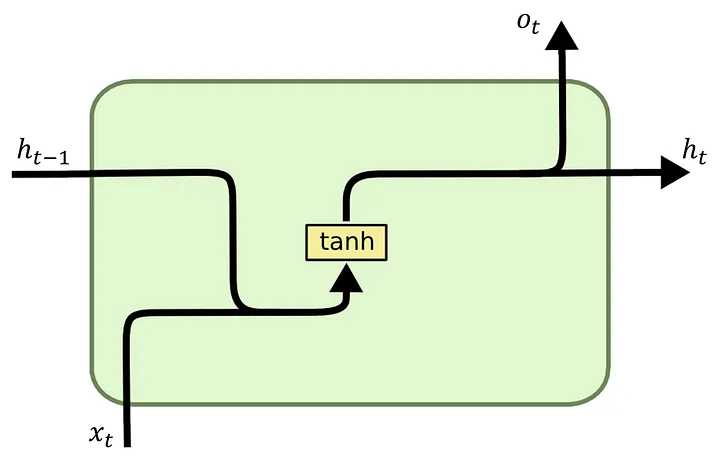

In [53]:
class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        self.W_ih = nn.Linear(input_size, hidden_size, bias=False) # Define a matriz de pesos de entrada
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=False) # Define a matriz de pesos de saída
        self.b_h = nn.Parameter(torch.zeros(hidden_size)) # Define o bias

    def forward(self, x, h):
        # x: (batch_size, input_size)
        # h: (batch_size, hidden_size)
        ht = torch.tanh(self.W_ih(x) + self.W_hh(h) + self.b_h)
        return ht

### **Exemplo de Uso da Célula RNN**

Inicialmente, definimos uma célula RNN com um tamanho de entrada de 10 e um tamanho de estado oculto de 4.

In [54]:
# Exemplo
input_size = 10
hidden_size = 4

rnn_cell = RNNCell(input_size, hidden_size)
print(rnn_cell)

RNNCell(
  (W_ih): Linear(in_features=10, out_features=4, bias=False)
  (W_hh): Linear(in_features=4, out_features=4, bias=False)
)


```
RNNCell(
  (W_ih): Linear(in_features=10, out_features=4, bias=False) - Matriz(4x10)
  (W_hh): Linear(in_features=4, out_features=4, bias=False) - Matriz(4x4)
)



### **Inspeção dos Parâmetros da Célula RNN**

Neste trecho de código, vamos inspecionar os parâmetros da célula RNN que acabamos de definir. Em uma rede neural, os parâmetros são os valores ajustáveis (como os pesos e bias) que a rede aprende durante o treinamento.

Ao executar o código, veremos os nomes e as formas dos parâmetros:

- **`W_ih`**: Matriz de pesos conectando a entrada ao estado oculto.
- **`W_hh`**: Matriz de pesos conectando o estado oculto anterior ao atual.
- **`b_h`**: Termo de bias para o estado oculto.

In [55]:
for name, param in rnn_cell.named_parameters():
    print(name, param.shape)

b_h torch.Size([4])
W_ih.weight torch.Size([4, 10])
W_hh.weight torch.Size([4, 4])


In [56]:
# pesos iniciais de uma RNN são aleatórios
print(rnn_cell.W_ih.weight)
print(rnn_cell.W_hh.weight)
print(rnn_cell.b_h)

Parameter containing:
tensor([[-0.2863, -0.1344,  0.2146,  0.3107,  0.2793,  0.0902,  0.0511,  0.1462,
          0.1647, -0.0252],
        [ 0.2037, -0.0830, -0.2740, -0.2407, -0.2123, -0.2320, -0.1328,  0.0968,
         -0.1900,  0.1696],
        [-0.0889, -0.1472, -0.1595, -0.0955, -0.0518, -0.2793,  0.0375, -0.1623,
         -0.1207,  0.2441],
        [-0.2732,  0.2007, -0.2001, -0.2352, -0.1986,  0.2260, -0.0809, -0.1192,
          0.2818,  0.1485]], requires_grad=True)
Parameter containing:
tensor([[ 0.1165,  0.0121, -0.1635,  0.3044],
        [-0.0088, -0.2534,  0.4187, -0.2973],
        [ 0.1674, -0.0536, -0.3639, -0.0734],
        [-0.1766,  0.4357,  0.2706, -0.3851]], requires_grad=True)
Parameter containing:
tensor([0., 0., 0., 0.], requires_grad=True)


#### **Explicação do Código**

No exemplo abaixo:
- Inicializamos uma entrada $x$ aleatória e um estado oculto inicial $h_{0}$ como zero.
- A célula RNN processa a entrada e gera um novo estado oculto.

In [57]:
x = torch.randn(input_size)
h = torch.zeros(hidden_size)

hn = rnn_cell(x, h)

hn.shape
print(hn)

tensor([ 0.3087, -0.4342, -0.2506, -0.1888], grad_fn=<TanhBackward0>)


### **Processamento de Sequências com RNN**

RNNs são projetadas para processar sequências de dados, onde cada passo de tempo depende dos passos anteriores. Vamos demonstrar isso processando uma sequência de entradas com a célula RNN.

#### **Explicação do Código**

Neste exemplo:
- Processamos uma sequência de 3 entradas $x$ e atualizamos o estado oculto $h$ a cada passo.
- O estado oculto é propagado ao longo da sequência, capturando informações temporais.

In [58]:
# Sequences
seq_len = 3 #Quantidade de passos de uma sequência

x = torch.randn(seq_len, input_size)
print(x)
h = torch.zeros(hidden_size)
print(h)

# Para cada instante de tempo
for i in range(seq_len):
    # Atualiza o estado oculto
    h = rnn_cell(x[i], h)
    print(f"Passo {i+1}")
    print(f"h = {h}")
    print()

tensor([[ 1.0908,  0.2610, -0.5185, -0.3294, -0.6135,  0.8050,  0.2830,  0.2955,
         -0.6090, -0.6935],
        [-0.7324,  0.2997, -0.8936, -1.0576,  0.9308,  2.0993, -0.4756,  0.8647,
         -1.0695, -1.0432],
        [-1.9603,  0.8832,  0.3347, -0.5977,  0.9851,  0.2893, -0.7606, -0.9857,
         -1.2995,  0.5960]])
tensor([0., 0., 0., 0.])
Passo 1
h = tensor([-0.5947,  0.3403, -0.3341, -0.0931], grad_fn=<TanhBackward0>)

Passo 2
h = tensor([ 0.0118, -0.3620, -0.5670,  0.5751], grad_fn=<TanhBackward0>)

Passo 3
h = tensor([ 0.4485, -0.5782,  0.4895,  0.0228], grad_fn=<TanhBackward0>)



### **Processamento de Sequências em Lote (Batched RNN)**

Para aumentar a eficiência, as RNNs podem processar várias sequências simultaneamente, usando o conceito de "batching". Cada sequência no lote é processada de forma independente, mas compartilhando os mesmos pesos da RNN.

#### **Explicação do Código**

Neste exemplo:
- Criamos um batch de 8 sequências, cada uma com 10 entradas.
- A célula RNN é aplicada ao batch, atualizando o estado oculto para cada sequência de forma paralela.

In [59]:
# Batched RNN
batch_size = 8 #Quantidade de sequências

x = torch.randn(batch_size, input_size)
print(x)
h = torch.zeros(batch_size, hidden_size)
print(h)

hn = rnn_cell(x, h)

hn.shape
print(hn)

tensor([[ 4.0619e-01, -4.6075e-01, -4.6011e-01, -6.1486e-01, -9.5796e-01,
          5.1860e-01,  2.3472e+00,  1.6107e+00,  5.9951e-02,  1.2633e+00],
        [-2.3981e-01,  2.2023e-01, -9.5807e-01,  1.3748e+00, -1.4649e+00,
         -6.4829e-01,  8.0740e-01,  1.6046e-01,  1.1964e+00, -1.3877e+00],
        [ 6.6458e-02,  2.6256e+00,  1.4980e+00,  1.0269e+00, -4.4882e-01,
          1.4344e-01, -1.1476e+00, -1.2600e+00, -1.4850e+00, -3.1349e-01],
        [ 1.7449e-01, -8.2825e-01,  3.5299e-01, -3.8205e-02,  1.1090e+00,
          9.4298e-01,  2.8396e-03, -1.3573e+00,  4.5200e-01, -1.9032e-01],
        [-2.2457e-01, -1.5022e+00, -1.2731e+00, -1.3877e+00,  4.9034e-01,
         -1.3015e-01, -5.3165e-02, -9.2005e-01, -3.5605e-01,  6.1020e-01],
        [-9.3852e-01,  1.7873e+00, -1.1448e+00, -1.0722e-01,  9.1130e-04,
          4.8493e-02, -8.3701e-01, -2.2281e+00, -2.9056e-01, -2.2586e+00],
        [ 9.1075e-01,  7.2413e-01,  1.0229e+00, -3.3366e-01, -9.6667e-01,
         -3.7895e-01,  8.8082e-0

### **Processamento de Sequências em Lote com Múltiplos Passos de Tempo**

Aqui, processamos um batch de sequências ao longo de vários passos de tempo.

#### **Explicação do Código**

Neste exemplo:
- Processamos um lote de 8 sequências, cada uma com 3 passos de tempo.
- Em cada passo de tempo, a célula RNN atualiza o estado oculto para todas as sequências do lote.

In [60]:
# Sequences
seq_len = 3

x = torch.randn(batch_size, seq_len, input_size)
print(x)
h = torch.zeros(batch_size, hidden_size)
print(h)

# Para cada instante de tempo
for i in range(seq_len):
    # Atualiza o estado oculto
    h = rnn_cell(x[:, i], h)
    print(f"Passo {i+1}")
    print(f"h = {h}")
    print()

tensor([[[-1.7502,  0.4529,  0.0308, -0.6692,  0.5351,  1.9107, -0.1280,
          -0.5626, -0.1682,  1.1532],
         [ 0.3146,  0.4433,  0.0277,  0.5797,  0.8522, -0.6634,  0.0496,
          -0.5576,  0.3831,  0.0207],
         [-1.1358,  0.2496,  0.4705, -0.0727, -0.3349,  1.4609,  1.8869,
           1.4991,  0.1428, -1.6198]],

        [[ 0.1210,  0.1274,  0.0431, -1.1393,  0.4053,  1.2188, -1.7205,
          -1.3692, -1.7314, -1.4464],
         [ 1.3022, -0.0455,  0.4529, -0.4628,  0.2162,  1.8665, -2.0470,
          -0.6977, -0.3532,  0.6121],
         [-0.0526,  1.2430, -1.4534,  0.0387,  0.1053, -1.3225,  1.0384,
           1.0280,  0.8684, -1.5091]],

        [[-0.0615, -0.5993, -0.6022,  0.5932, -0.0975, -0.9336,  1.0973,
          -0.1525, -0.5982,  0.2005],
         [ 1.6809,  0.8883, -0.6437,  0.3837,  0.3149, -0.6590,  0.3525,
          -1.7533, -0.2025,  0.6424],
         [ 0.9473, -0.0468,  0.1666,  1.2502, -2.5686,  0.9036, -0.7146,
           1.6558,  0.7898,  2.3734

##exemplo de explicação:

As 8 sequências são treinadas simultaneamente(compartilhando apenas os mesmos pesos)

```
Passo 1
h = tensor([[-0.0438,  0.1989,  0.0074,  0.1652],estado oculto da sequência 1 no passo 1
        [ 0.3337, -0.1868, -0.8451,  0.7726], sequência 2
        [ 0.6917, -0.8661, -0.3173,  0.4594], sequência 3...
        [-0.3706, -0.4161, -0.0887, -0.2166],
        [-0.2742,  0.7103,  0.0168, -0.5107],
        [ 0.3707,  0.3499,  0.1797, -0.0126],
        [ 0.3681,  0.1385, -0.1251,  0.0369],
        [ 0.1278,  0.2721,  0.4497, -0.2532]]

```




### **Construção de uma Rede RNN Completa**

Vamos expandir a célula RNN que criamos anteriormente para uma rede RNN completa. A rede RNN será composta por uma célula RNN seguida por uma camada linear que produzirá a saída final.

#### **Explicação do Código**

- **`self.cell`**: Instância da célula RNN que processará cada passo da sequência.
- **`self.W_ho`**: Camada linear que mapeia o estado oculto final para a saída desejada.

No método `forward`:
- **Entrada (`x`)**: Um tensor de forma `(batch_size, seq_len, input_size)`, onde `seq_len` é o comprimento da sequência.
- **Estado oculto (`h`)**: Se não for fornecido, é inicializado como um vetor de zeros.
- **Processamento da sequência**: A entrada é processada passo a passo pela célula RNN.
- **Saída (`y`)**: Calculada pela camada linear a partir do estado oculto final.

In [61]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.cell = RNNCell(input_size, hidden_size) # Define a célula RNN
        self.W_ho = nn.Linear(hidden_size, output_size) # Define a matriz de pesos de saída

    def forward(self, x, h=None):
        # x: (batch_size, seq_len, input_size)
        batch_size, seq_len, _ = x.size()

        # h: (batch_size, hidden_size)
        if h is None:
            h = torch.zeros(batch_size, self.hidden_size)
        h = h.to(x.device)

        # Processa a sequência
        for i in range(seq_len):
            h = self.cell(x[:, i], h)

        # Calcula a saída
        y = self.W_ho(h)
        return y

### **Geração de Dados para Treinamento**

Para treinar a RNN, precisamos de um conjunto de dados sequenciais. Neste exemplo, geramos uma série temporal baseada em uma função senoide com ruído adicionado.

#### **Explicação do Código**

- **`x`**: Sequência de pontos no intervalo $[0, 6\pi]$.
- **`y`**: Valores da função senoide com ruído gaussiano adicionado.

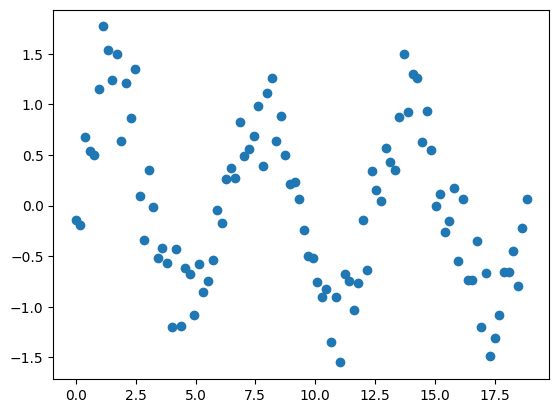

In [62]:
num_points = 100

x = np.linspace(0, 6*np.pi, num_points)
y = np.sin(x) + np.random.normal(0, 0.3, num_points)

plt.scatter(x, y)
plt.show()

### **Preparação das Sequências de Treinamento**

Agora, preparamos as entradas e as saídas alvo para o treinamento da RNN. Cada sequência de entrada será usada para prever o próximo ponto na série temporal.

#### **Explicação do Código**

- **`sequence_length`**: O comprimento da janela da sequência usada como entrada.
- **`inputs`**: Sequências de tamanho `sequence_length` extraídas dos dados.
- **`targets`**: O ponto subsequente na sequência que a rede deve prever.
- **Tensorização**: As sequências são convertidas em tensores PyTorch para uso na rede neural.

In [63]:
sequence_length = 20 # a RNN começa a prever a partir do ponto de índice 20.
batch_size = num_points - sequence_length #As sequências para prever cada um dos próximos 80 pontos individualmente
inputs = []
targets = []

for i in range(num_points - sequence_length):
    inputs.append(y[i:i+sequence_length]) # inputs[0] = y[0:20] → valores de índice 0 a 19
    targets.append(y[i+sequence_length]) # targets[0] = y[20] → valor de índice 20

inputs = torch.tensor(inputs, dtype=torch.float32).unsqueeze(-1)  # Shape: (batch_size, window_size, 1)
print(inputs)
targets = torch.tensor(targets, dtype=torch.float32).unsqueeze(-1)  # Shape: (batch_size, 1)
print(targets)

tensor([[[-0.1417],
         [-0.1926],
         [ 0.6763],
         ...,
         [-0.0133],
         [-0.5155],
         [-0.4207]],

        [[-0.1926],
         [ 0.6763],
         [ 0.5420],
         ...,
         [-0.5155],
         [-0.4207],
         [-0.5659]],

        [[ 0.6763],
         [ 0.5420],
         [ 0.4979],
         ...,
         [-0.4207],
         [-0.5659],
         [-1.2004]],

        ...,

        [[ 0.9295],
         [ 0.5521],
         [-0.0067],
         ...,
         [-0.6585],
         [-0.6591],
         [-0.4474]],

        [[ 0.5521],
         [-0.0067],
         [ 0.1158],
         ...,
         [-0.6591],
         [-0.4474],
         [-0.7952]],

        [[-0.0067],
         [ 0.1158],
         [-0.2596],
         ...,
         [-0.4474],
         [-0.7952],
         [-0.2249]]])
tensor([[-0.5659],
        [-1.2004],
        [-0.4334],
        [-1.1919],
        [-0.6151],
        [-0.6780],
        [-1.0846],
        [-0.5750],
        [-0.8524],

### **Inicialização da Rede RNN e do Otimizador**

Nesta seção, instanciamos a rede RNN com os tamanhos de entrada, estado oculto, e saída definidos. Também configuramos o critério de perda e o otimizador.

#### **Explicação do Código**

- **`input_size`**: Dimensão da entrada (1, já que estamos lidando com uma série temporal univariada).
- **`hidden_size`**: Número de unidades no estado oculto.
- **`output_size`**: Dimensão da saída (1, pois queremos prever um único valor por vez).

In [64]:
input_size = 1
hidden_size = 8
output_size = 1

rnn = RNN(input_size, hidden_size, output_size)

In [65]:
criterion = nn.MSELoss()
optimizer = optim.Adam(rnn.parameters(), lr=0.01)

In [66]:
# Treinamento
num_epochs = 500
for epoch in range(num_epochs):
    optimizer.zero_grad()

    predictions = rnn(inputs)
    loss = criterion(predictions, targets)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: 0.7668418884277344
Epoch 50, Loss: 0.12517623603343964
Epoch 100, Loss: 0.09517787396907806
Epoch 150, Loss: 0.07226543128490448
Epoch 200, Loss: 0.0648951455950737
Epoch 250, Loss: 0.05769381672143936
Epoch 300, Loss: 0.049703776836395264
Epoch 350, Loss: 0.0430917851626873
Epoch 400, Loss: 0.03887798264622688
Epoch 450, Loss: 0.02926034666597843


### **Geração de Predições com a Rede Treinada**

Após o treinamento, usamos a RNN para gerar previsões de uma nova série temporal. A ideia é prever a continuação da senoide a partir de uma sequência inicial.

#### **Explicação do Código**

- **`predicted_wave`**: Lista para armazenar as predições feitas pela RNN.
- **`input_seq`**: Sequência inicial usada para começar a predição.
- **Passos de predição**:
  - A cada passo, a rede faz uma nova predição que é adicionada à sequência de entrada.
  - A janela de entrada é atualizada para incluir a nova predição e excluir o ponto mais antigo.

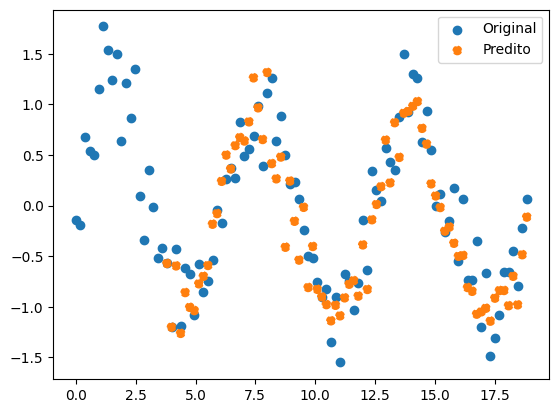

In [67]:
# Gerando predições para uma senoide
predicted_wave = []

#dentro do reshape:
#1 - batch size( quantidade de sequências simltaneas treinadas)
#3 - número de features por passo de tempo (aqui é só 1 valor por tempo)
input_seq = y[:sequence_length].reshape(1, sequence_length, 1)
input_seq = torch.tensor(input_seq, dtype=torch.float32)

for _ in range(num_points - sequence_length):
    predicted_next = rnn(input_seq)
    predicted_wave.append(predicted_next.item())

    # Arrasta a janela de entrada
    predicted_next = predicted_next.view(1, 1, 1)  # Reshape para (1, 1, 1)
    input_seq = torch.cat([input_seq[:, 1:, :], predicted_next], dim=1) # Remove o primeiro elemento e adiciona a predição

# Plota a senoide original e a predição
plt.scatter(x, y, label='Original')
plt.scatter(x[sequence_length:], predicted_wave, label='Predito', linestyle='dashed')
plt.legend()
plt.show()

#Pratica*
## Pratica em grupo, 1 integrante do grupo deve enviar esse notebook com o nome completo de cada integrante do grupo na célula a baixo. Integrante do grupo que não tenha o nome na célula não receberá nota.

### **(40ps) Exercício 1: Aumentando o Tamanho do Estado Oculto**

1. Aumente o tamanho do estado oculto (`hidden_size`) na rede RNN.
2. Treine a rede novamente com os mesmos dados de entrada.
3. Compare a perda final e as predições da rede com o modelo original.
4. Pergunta: Como o aumento do tamanho do estado oculto afetou o desempenho da rede?

### **(40ps) Exercício 2: Predição de Longo Prazo**

1. Use a RNN treinada para prever 100 pontos futuros da senoide a partir de uma nova sequência inicial de 20 pontos.
2. Aumente o número de camadas ocultas e tente novamente.
2. Compare as predições com a senoide original.
3. Pergunta: A rede consegue manter a forma da senoide por um longo período de predição? O que acontece com as predições ao longo do tempo?

### **(20ps) Exercício 3: Adicionando Ruído**

1. Adicione um ruído gaussiano mais forte à série temporal original (aumente a variância do ruído).
2. Treine a RNN com essa série temporal ruidosa.
3. Compare as predições com o modelo treinado com menos ruído.
4. Pergunta: Como o aumento do ruído nos dados de entrada impacta a capacidade da RNN de prever corretamente a série temporal?

# Nomes dos integrantes do grupo em ordem alfabética:

---




*   
*   


#1

In [68]:
#1
input_size = 1
hidden_size = 15
output_size = 1

rnn = RNN(input_size, hidden_size, output_size)

In [69]:
criterion = nn.MSELoss()
optimizer = optim.Adam(rnn.parameters(), lr=0.01)

In [70]:
# Treinamento
num_epochs = 500
for epoch in range(num_epochs):
    optimizer.zero_grad()

    predictions = rnn(inputs)
    loss = criterion(predictions, targets)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: 1.1733763217926025
Epoch 50, Loss: 0.08528681099414825
Epoch 100, Loss: 0.05098040774464607
Epoch 150, Loss: 0.02874767780303955
Epoch 200, Loss: 0.02087351307272911
Epoch 250, Loss: 0.013516348786652088
Epoch 300, Loss: 0.007900475524365902
Epoch 350, Loss: 0.0038117687217891216
Epoch 400, Loss: 0.015037039294838905
Epoch 450, Loss: 0.008174239657819271


#2

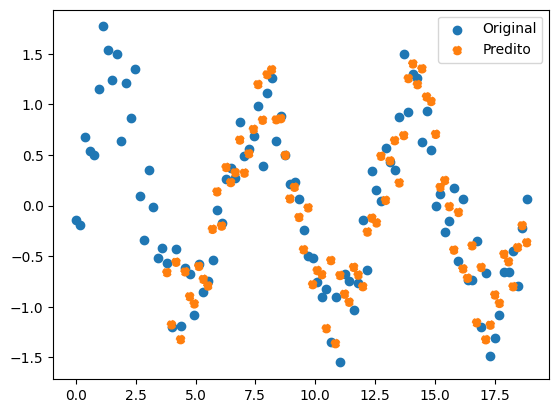

In [71]:
# Gerando predições para uma senoide
predicted_wave = []

#dentro do reshape:
#1 - batch size( quantidade de sequências simltaneas treinadas)
#3 - número de features por passo de tempo (aqui é só 1 valor por tempo)
input_seq = y[:sequence_length].reshape(1, sequence_length, 1)
input_seq = torch.tensor(input_seq, dtype=torch.float32)

for _ in range(num_points - sequence_length):
    predicted_next = rnn(input_seq)
    predicted_wave.append(predicted_next.item())

    # Arrasta a janela de entrada
    predicted_next = predicted_next.view(1, 1, 1)  # Reshape para (1, 1, 1)
    input_seq = torch.cat([input_seq[:, 1:, :], predicted_next], dim=1) # Remove o primeiro elemento e adiciona a predição

# Plota a senoide original e a predição
plt.scatter(x, y, label='Original')
plt.scatter(x[sequence_length:], predicted_wave, label='Predito', linestyle='dashed')
plt.legend()
plt.show()

#3

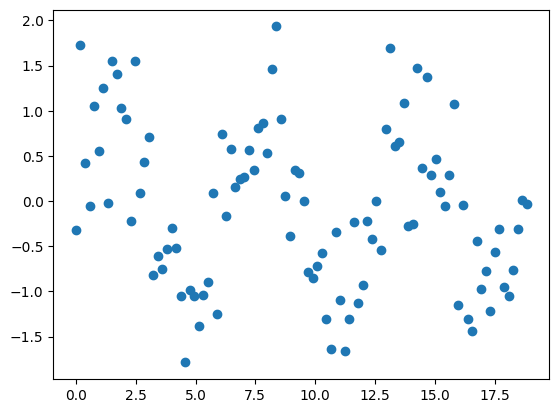

In [72]:
num_points = 100

x = np.linspace(0, 6*np.pi, num_points)
y = np.sin(x) + np.random.normal(0, 0.5, num_points)

plt.scatter(x, y)
plt.show()

In [73]:
sequence_length = 20 # a RNN começa a prever a partir do ponto de índice 20.
batch_size = num_points - sequence_length #As sequências para prever cada um dos próximos 80 pontos individualmente
inputs = []
targets = []

for i in range(num_points - sequence_length):
    inputs.append(y[i:i+sequence_length]) # inputs[0] = y[0:20] → valores de índice 0 a 19
    targets.append(y[i+sequence_length]) # targets[0] = y[20] → valor de índice 20

inputs = torch.tensor(inputs, dtype=torch.float32).unsqueeze(-1)  # Shape: (batch_size, window_size, 1)
print(inputs)
targets = torch.tensor(targets, dtype=torch.float32).unsqueeze(-1)  # Shape: (batch_size, 1)
print(targets)

tensor([[[-0.3176],
         [ 1.7276],
         [ 0.4173],
         ...,
         [-0.8154],
         [-0.6052],
         [-0.7525]],

        [[ 1.7276],
         [ 0.4173],
         [-0.0570],
         ...,
         [-0.6052],
         [-0.7525],
         [-0.5315]],

        [[ 0.4173],
         [-0.0570],
         [ 1.0568],
         ...,
         [-0.7525],
         [-0.5315],
         [-0.2945]],

        ...,

        [[ 1.3677],
         [ 0.2930],
         [ 0.4705],
         ...,
         [-0.9543],
         [-1.0522],
         [-0.7663]],

        [[ 0.2930],
         [ 0.4705],
         [ 0.1011],
         ...,
         [-1.0522],
         [-0.7663],
         [-0.3088]],

        [[ 0.4705],
         [ 0.1011],
         [-0.0520],
         ...,
         [-0.7663],
         [-0.3088],
         [ 0.0147]]])
tensor([[-0.5315],
        [-0.2945],
        [-0.5252],
        [-1.0537],
        [-1.7875],
        [-0.9823],
        [-1.0489],
        [-1.3847],
        [-1.0408],

In [74]:
# Treinamento
num_epochs = 500
for epoch in range(num_epochs):
    optimizer.zero_grad()

    predictions = rnn(inputs)
    loss = criterion(predictions, targets)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: 0.46580058336257935
Epoch 50, Loss: 0.16247963905334473
Epoch 100, Loss: 0.09634841978549957
Epoch 150, Loss: 0.18548759818077087
Epoch 200, Loss: 0.04523174464702606
Epoch 250, Loss: 0.022871728986501694
Epoch 300, Loss: 0.010615380480885506
Epoch 350, Loss: 0.0053780460730195045
Epoch 400, Loss: 0.0028900557663291693
Epoch 450, Loss: 0.0017853155732154846


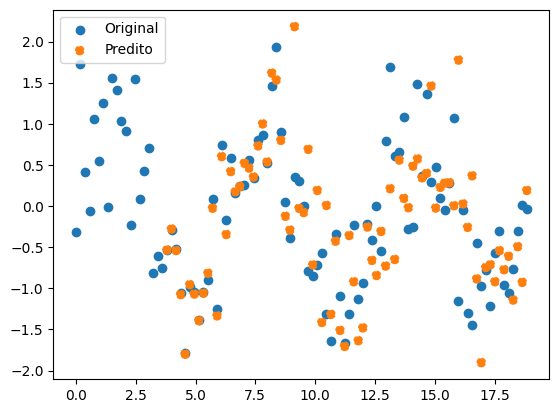

In [75]:
# Gerando predições para uma senoide
predicted_wave = []

#dentro do reshape:
#1 - batch size( quantidade de sequências simltaneas treinadas)
#3 - número de features por passo de tempo (aqui é só 1 valor por tempo)
input_seq = y[:sequence_length].reshape(1, sequence_length, 1)
input_seq = torch.tensor(input_seq, dtype=torch.float32)

for _ in range(num_points - sequence_length):
    predicted_next = rnn(input_seq)
    predicted_wave.append(predicted_next.item())

    # Arrasta a janela de entrada
    predicted_next = predicted_next.view(1, 1, 1)  # Reshape para (1, 1, 1)
    input_seq = torch.cat([input_seq[:, 1:, :], predicted_next], dim=1) # Remove o primeiro elemento e adiciona a predição

# Plota a senoide original e a predição
plt.scatter(x, y, label='Original')
plt.scatter(x[sequence_length:], predicted_wave, label='Predito', linestyle='dashed')
plt.legend()
plt.show()